In [1]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import wrf
from matplotlib.cm import get_cmap
from netCDF4 import Dataset


class WRFDataset(Dataset):
    """
    A custom wrapper around the NetCDF4 Dataset.
    It manually tells Python how to 'pickel' (copy) the file,
    solving the NotImplementedError in wrf-python.
    """
    def __init__(self, filename, **kwargs):
        super().__init__(filename, **kwargs)

    def __reduce__(self):
        # This method handles the "copying" that wrf-python tries to do
        return (self.__class__, (self.filepath(),))

%matplotlib inline

c:\Users\bruno\.conda\envs\wrf\lib\site-packages\wrf\__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def create_base_map(variable):
    cart_proj = wrf.get_cartopy(variable)
    lats, lons = wrf.latlon_coords(variable)

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=cart_proj)

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    ax.set_xlim(wrf.cartopy_xlim(variable))
    ax.set_ylim(wrf.cartopy_ylim(variable))

    return fig, ax, lats, lons

In [ ]:
def plot_wind_10m(ncfile, thinning=10):
    print("Processing Wind Data...")

    # Extract destaggered, earth-relative wind variables
    uv_met = wrf.getvar(ncfile, "uvmet10", units="m/s")
    wspd = wrf.getvar(ncfile, "wspd10", units="m/s")

    u_met, v_met = uv_met[0, :], uv_met[1, :]

    # Create Map
    fig, ax, lats, lons = create_base_map(wspd)

    # Plot Wind Speed (Color)
    levels = np.arange(0, 25, 1)
    contour = plt.contourf(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(wspd),
                           levels=levels, transform=ccrs.PlateCarree(),
                           cmap=get_cmap("viridis"), extend='max')

    plt.colorbar(contour, ax=ax, orientation="vertical", pad=0.05, label="Wind Speed (m/s)")

    # Plot Vectors (Arrows)
    Q = plt.quiver(wrf.to_np(lons)[::thinning, ::thinning],
                   wrf.to_np(lats)[::thinning, ::thinning],
                   wrf.to_np(u_met)[::thinning, ::thinning],
                   wrf.to_np(v_met)[::thinning, ::thinning],
                   transform=ccrs.PlateCarree(),
                   color='white', scale=200, width=0.002)

    ax.quiverkey(Q, 0.9, 0.9, 10, r'$10 \frac{m}{s}$', labelpos='E', coordinates='axes', color='white')

    plt.title("10m Wind Speed & Vectors")
    plt.show()

In [9]:
def plot_pressure_mean(ncfile):
    print("Processing Mean Pressure...")

    # 1. Get all data (This variable HAS metadata)
    slp_all = wrf.getvar(ncfile, "slp", units="hPa", timeidx=wrf.ALL_TIMES)

    # 2. Calculate Mean (This result LOST metadata)
    slp_mean = np.mean(slp_all, axis=0)

    # 3. Create Map using 'slp_all' as the reference for projection
    # (We use the original variable to set up the map)
    fig, ax, lats, lons = create_base_map(slp_all)

    # 4. Plot the MEAN data
    # We use to_np(lons) and to_np(lats) from the original,
    # but plot the NEW 'slp_mean' array.
    contour_fill = plt.contourf(wrf.to_np(lons), wrf.to_np(lats), slp_mean,
                                levels=20, transform=ccrs.PlateCarree(),
                                cmap=get_cmap("jet"))

    plt.colorbar(contour_fill, ax=ax, label="Mean SLP (hPa)")

    # Contours
    contour_lines = plt.contour(wrf.to_np(lons), wrf.to_np(lats), slp_mean,
                                levels=10, transform=ccrs.PlateCarree(),
                                colors="black", linewidths=0.8)
    plt.clabel(contour_lines, inline=1, fontsize=10, fmt='%1.0f')

    plt.title("Mean Sea Level Pressure (Whole Simulation)")
    plt.show()

In [10]:
def plot_sea_temperature(ncfile, time_idx=0):
    print("Processing Sea Temperature...")

    # 1. Get Variables
    # T2 = Temperature at 2 meters
    t2 = wrf.getvar(ncfile, "T2", timeidx=time_idx)
    landmask = wrf.getvar(ncfile, "LANDMASK", timeidx=time_idx)

    # 2. Convert Kelvin to Celsius
    t2_c = t2 - 273.15

    # 3. Apply Mask (Hide Land)
    # mask where landmask == 1 (Land)
    t2_sea_only = np.ma.masked_where(landmask == 1, t2_c)

    # 4. Create Map
    # Use 't2' as reference for projection
    fig, ax, lats, lons = create_base_map(t2)

    # 5. Plot
    # Use a specific range (vmin, vmax) if you want to see contrast better
    contour = plt.contourf(wrf.to_np(lons), wrf.to_np(lats), t2_sea_only,
                           levels=25,
                           transform=ccrs.PlateCarree(),
                           cmap=get_cmap("coolwarm"),
                           extend='both')

    cbar = plt.colorbar(contour, ax=ax, orientation="vertical", pad=0.05)
    cbar.set_label("Sea Surface Temperature (°C)")

    plt.title(f"Sea Surface Temperature (Land Masked) - Step {time_idx}")
    plt.show()

In [5]:
ncfile = WRFDataset("wrfout_d04_2013-01-01_00_00_00")

Processing Wind Data...


C:\Users\bruno\AppData\Local\Temp\ipykernel_21380\871746612.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap("viridis"), extend='max')
c:\Users\bruno\.conda\envs\wrf\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\bruno\.conda\envs\wrf\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\bruno\.conda\envs\wrf\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_p

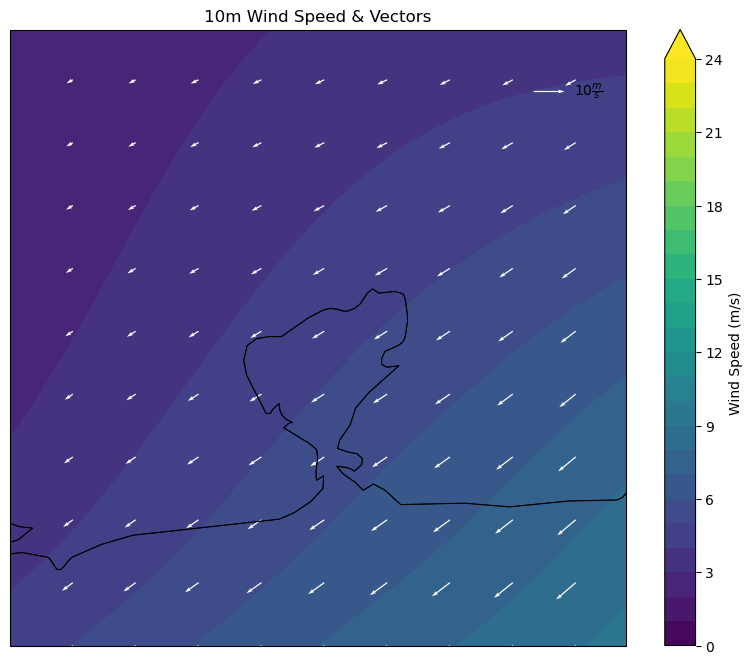

In [6]:
plot_wind_10m(ncfile, thinning=10)

Processing Mean Pressure...


C:\Users\bruno\AppData\Local\Temp\ipykernel_21380\2432457271.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap("jet"))


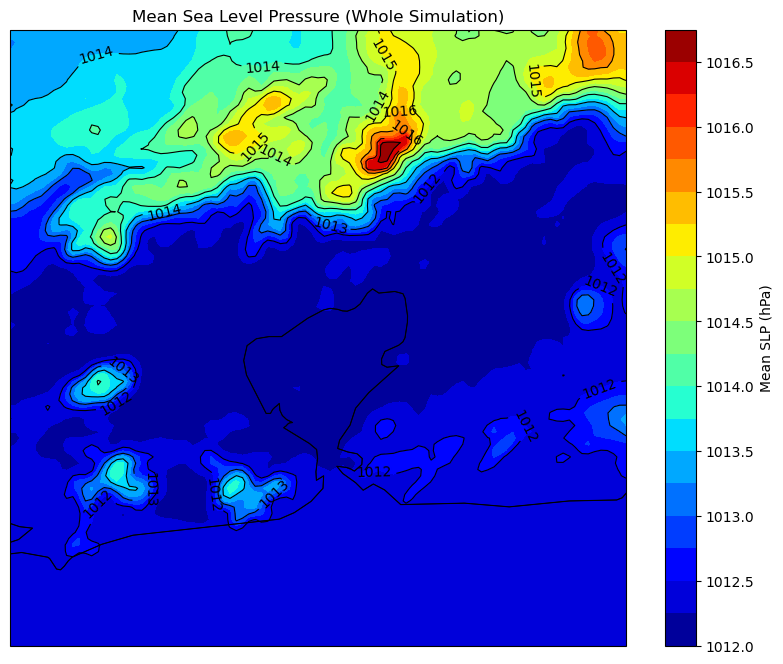

In [11]:
plot_pressure_mean(ncfile)

Processing Sea Temperature...


C:\Users\bruno\AppData\Local\Temp\ipykernel_21380\710661184.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap("coolwarm"),


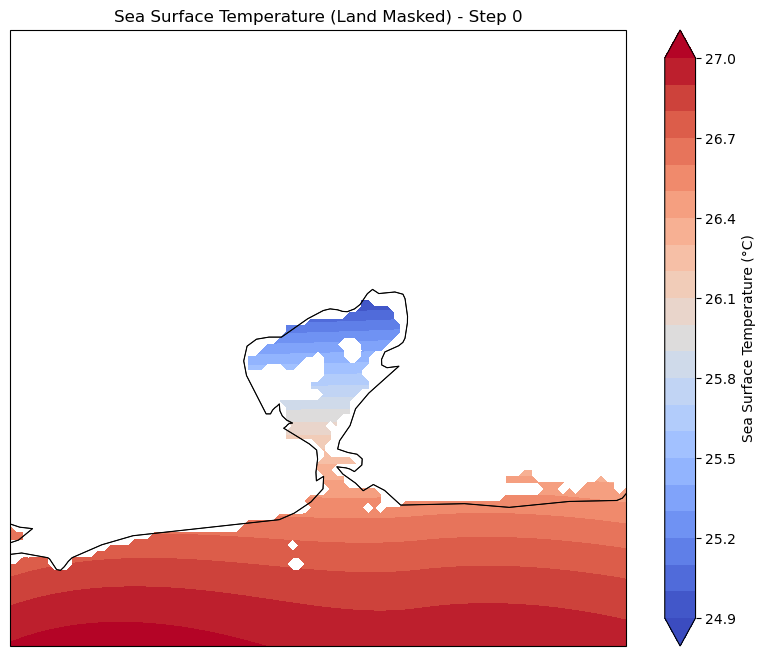

In [12]:
plot_sea_temperature(ncfile, time_idx=0)